# Clustering
## Conjuntos de datos
Fuente: https://scikit-learn.org/stable/auto_examples/cluster/plot_cluster_comparison.html

In [82]:
import numpy as np
import pandas as pd
from sklearn import datasets
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="darkgrid")

Solo normalizamos si no existe una correlación entre las variables. En caso contrario debemos mantener la escala porque los algoritmos de clustering por lo general utilizan medidas de distancia y la distorsion de los datos puede afectar al rendimiento del algoritmo.

### Anillos

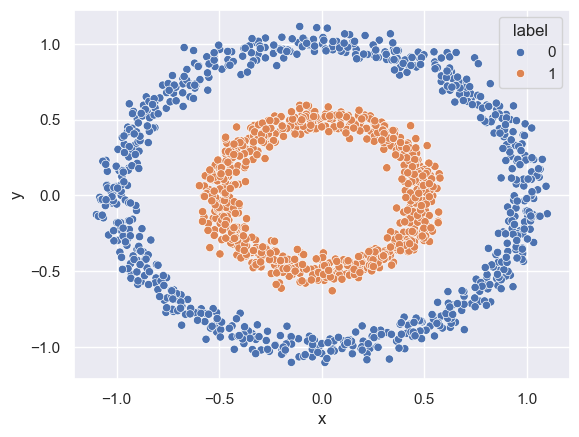

In [83]:
n_samples = 1500
noisy_circles = datasets.make_circles(n_samples=n_samples, factor=.5, noise=.05)
df_noisy_circles = pd.DataFrame({'x':noisy_circles[0][:,0], 'y':noisy_circles[0][:,1], 'label': noisy_circles[1]})
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_noisy_circles)

### Lunas

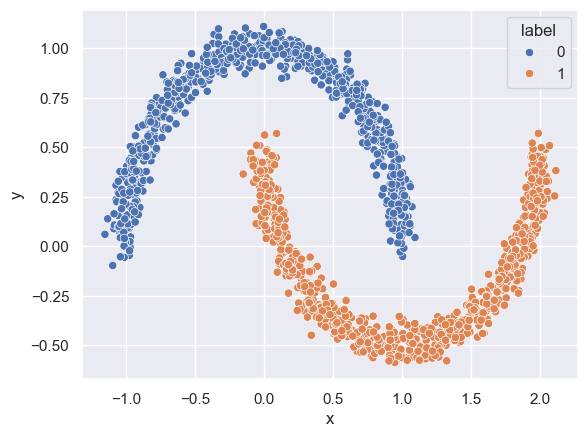

In [84]:
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=.05)
df_noisy_moons = pd.DataFrame({'x':noisy_moons[0][:,0], 'y':noisy_moons[0][:,1], 'label': noisy_moons[1]})
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_noisy_moons)

### Clusters esféricos

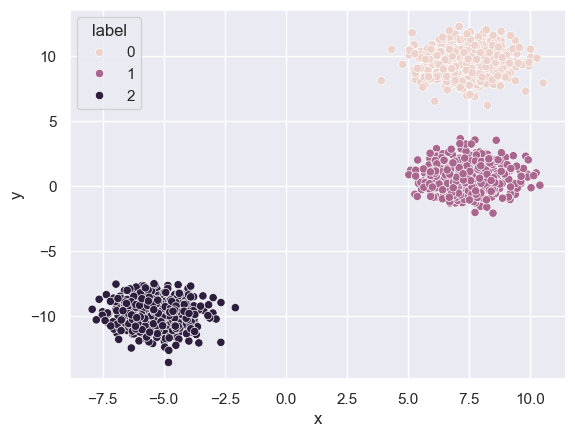

In [85]:
blobs = datasets.make_blobs(n_samples=n_samples, random_state=8)
df_blobs = pd.DataFrame({'x':blobs[0][:,0], 'y':blobs[0][:,1], 'label': blobs[1]})
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_blobs)

### Clusteres esféricos con diferentes varianzas

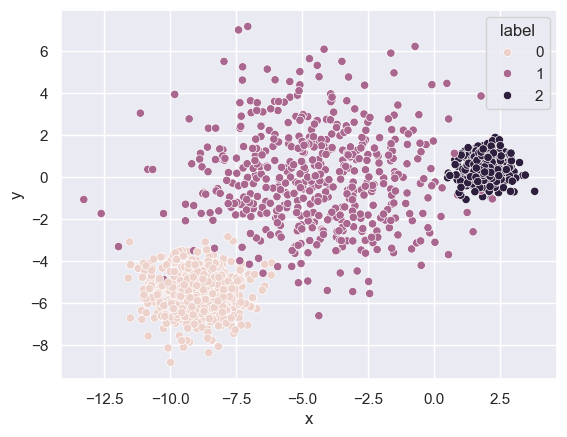

In [86]:
# blobs with varied variances
random_state = 170
varied = datasets.make_blobs(n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state)
df_varied = pd.DataFrame({'x':varied[0][:,0], 'y':varied[0][:,1], 'label': varied[1]})
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_varied)

### Clusteres anisotrópicos

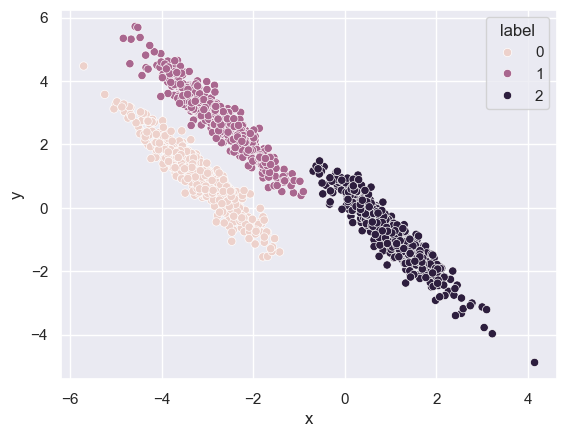

In [87]:
# Anisotropicly distributed data
random_state = 170
X, y = datasets.make_blobs(n_samples=n_samples, random_state=random_state)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)
df_aniso = pd.DataFrame({'x':X_aniso[:,0], 'y':X_aniso[:,1], 'label': y})
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_aniso)

### Datos no estructurados

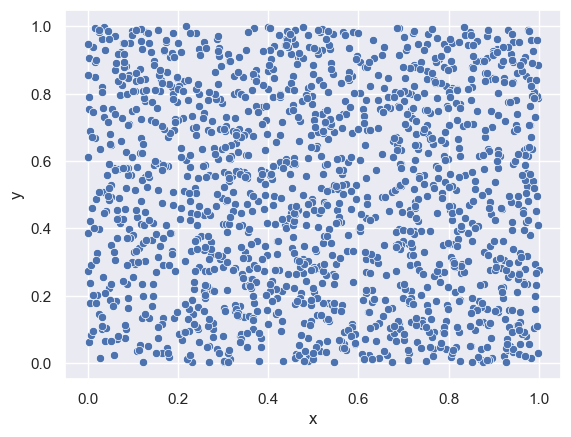

In [88]:
no_structure = np.random.rand(n_samples, 2), None
df_no_structure = pd.DataFrame({'x':no_structure[0][:,0], 'y':no_structure[0][:,1]})
ax = sns.scatterplot(x='x', y='y', data=df_no_structure)

## PARTICIONES: k-Means

In [89]:
from sklearn.cluster import KMeans

### Conjuntos de datos para los que muestra un BUEN funcionamiento

### Conjuntos de datos para los que muestra un MAL funcionamiento

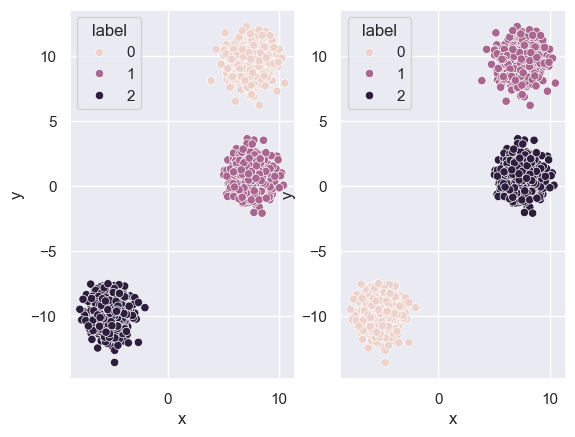

In [90]:
labels = KMeans(n_clusters=3).fit(blobs[0]).labels_
df_blobs_pred = pd.DataFrame({'x':blobs[0][:,0], 'y':blobs[0][:,1], 'label': labels})
fig, axs = plt.subplots(ncols=2)
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_blobs, ax=axs[0])
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_blobs_pred, ax=axs[1])

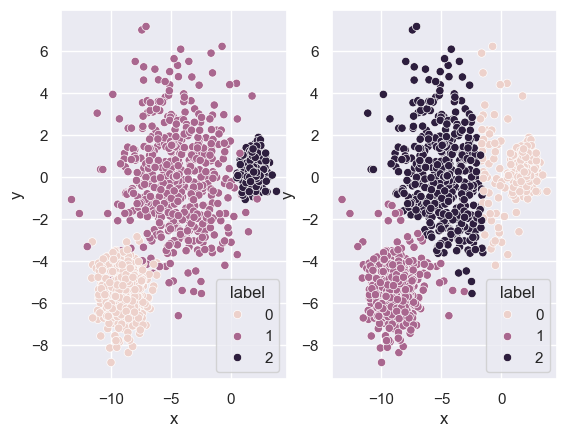

In [91]:
labels = KMeans(n_clusters=3).fit(varied[0]).labels_
df_varied_pred = pd.DataFrame({'x':varied[0][:,0], 'y':varied[0][:,1], 'label': labels})
fig, axs = plt.subplots(ncols=2)
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_varied, ax=axs[0])
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_varied_pred, ax=axs[1])

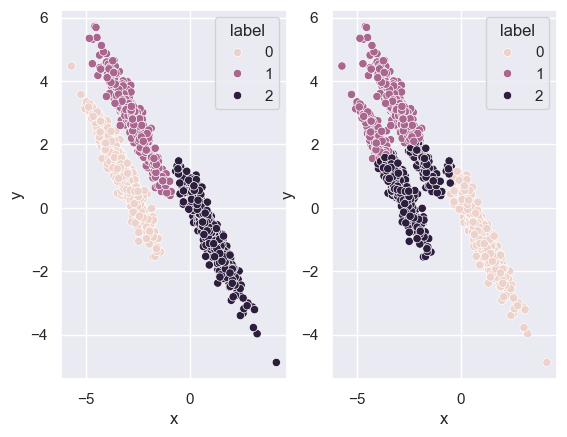

In [92]:
labels = KMeans(n_clusters=3).fit(X_aniso).labels_
df_aniso_pred = pd.DataFrame({'x':X_aniso[:,0], 'y':X_aniso[:,1], 'label': labels})
fig, axs = plt.subplots(ncols=2)
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_aniso, ax=axs[0])
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_aniso_pred, ax=axs[1])

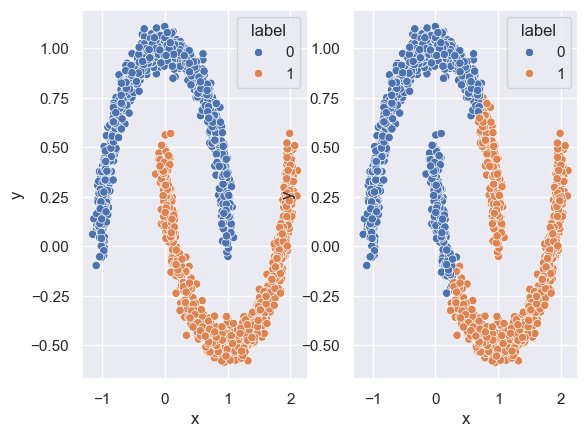

In [93]:
labels = KMeans(n_clusters=2).fit(noisy_moons[0]).labels_
df_noisy_moons_pred = pd.DataFrame({'x':noisy_moons[0][:,0], 'y':noisy_moons[0][:,1], 'label': labels})
fig, axs = plt.subplots(ncols=2)
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_noisy_moons, ax=axs[0])
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_noisy_moons_pred, ax=axs[1])

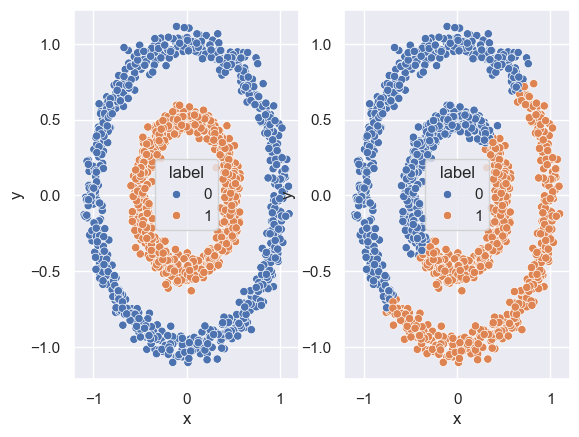

In [94]:
labels = KMeans(n_clusters=2).fit(noisy_circles[0]).labels_
df_noisy_circles_pred = pd.DataFrame({'x':noisy_circles[0][:,0], 'y':noisy_circles[0][:,1], 'label': labels})
fig, axs = plt.subplots(ncols=2)
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_noisy_circles, ax=axs[0])
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_noisy_circles_pred, ax=axs[1])

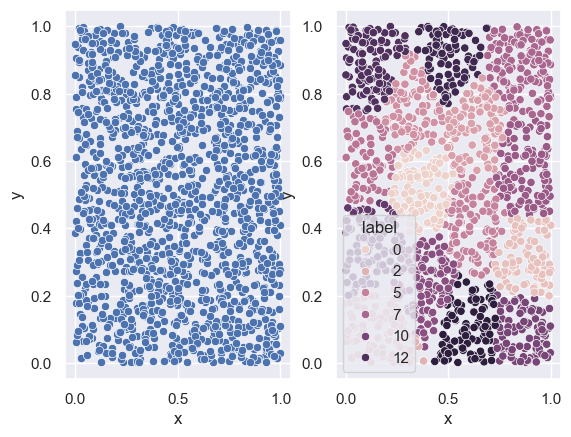

In [95]:
labels = KMeans(n_clusters=15).fit(no_structure[0]).labels_
df_no_structure_pred = pd.DataFrame({'x':no_structure[0][:,0], 'y':no_structure[0][:,1], 'label': labels})
fig, axs = plt.subplots(ncols=2)
ax = sns.scatterplot(x='x', y='y', data=df_no_structure, ax=axs[0])
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_no_structure_pred, ax=axs[1])

## JERARQUICO:

## Agglomerative 

In [96]:
from sklearn.cluster import AgglomerativeClustering

### Conjuntos de datos para los que muestra un BUEN funcionamiento

### Conjuntos de datos para los que muestra un MAL funcionamiento

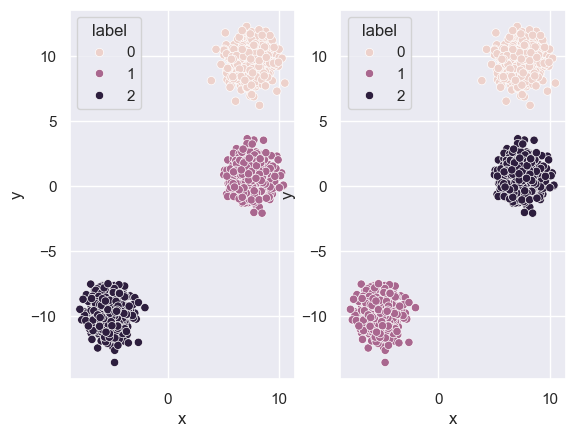

In [97]:
labels = AgglomerativeClustering(n_clusters=3,linkage="complete").fit(blobs[0]).labels_
df_blobs_pred = pd.DataFrame({'x':blobs[0][:,0], 'y':blobs[0][:,1], 'label': labels})
fig, axs = plt.subplots(ncols=2)
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_blobs, ax=axs[0])
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_blobs_pred, ax=axs[1])

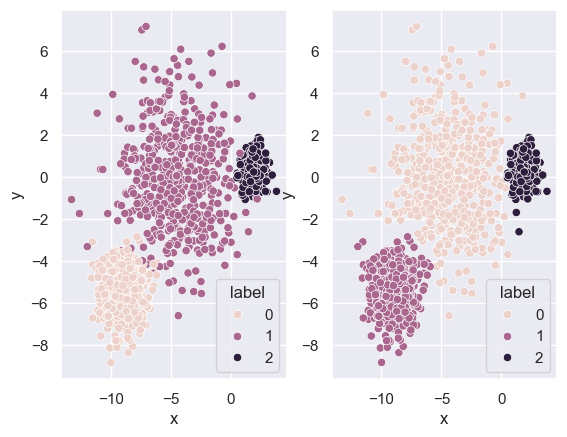

In [98]:
labels = AgglomerativeClustering(n_clusters=3,linkage="ward").fit(varied[0]).labels_
df_varied_pred = pd.DataFrame({'x':varied[0][:,0], 'y':varied[0][:,1], 'label': labels})
fig, axs = plt.subplots(ncols=2)
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_varied, ax=axs[0])
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_varied_pred, ax=axs[1])

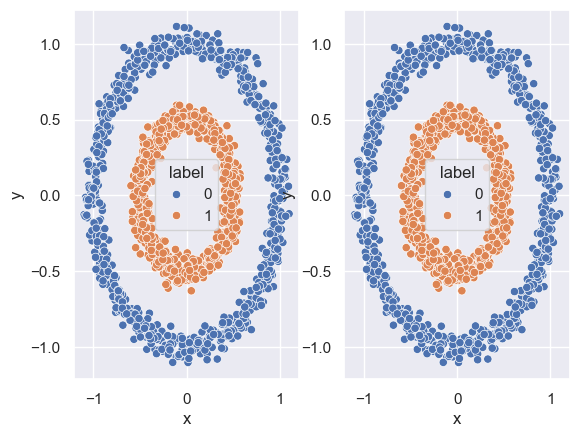

In [99]:
labels = AgglomerativeClustering(n_clusters=2,linkage="single").fit(noisy_circles[0]).labels_
df_noisy_circles_pred = pd.DataFrame({'x':noisy_circles[0][:,0], 'y':noisy_circles[0][:,1], 'label': labels})
fig, axs = plt.subplots(ncols=2)
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_noisy_circles, ax=axs[0])
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_noisy_circles_pred, ax=axs[1])

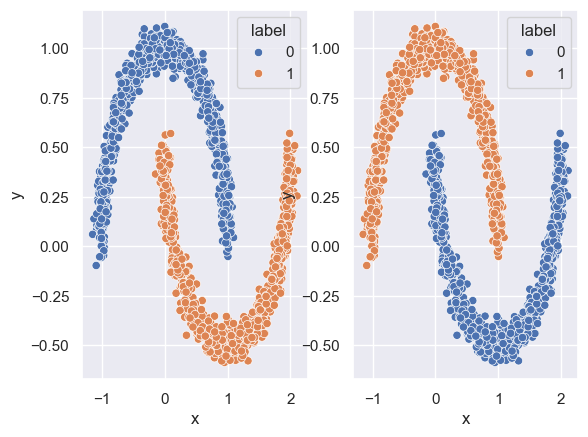

In [100]:
labels = AgglomerativeClustering(n_clusters=2,linkage="single").fit(noisy_moons[0]).labels_
df_noisy_moons_pred = pd.DataFrame({'x':noisy_moons[0][:,0], 'y':noisy_moons[0][:,1], 'label': labels})
fig, axs = plt.subplots(ncols=2)
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_noisy_moons, ax=axs[0])
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_noisy_moons_pred, ax=axs[1])

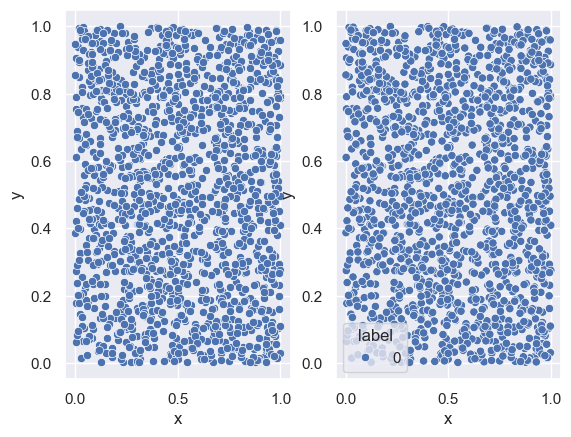

In [101]:
labels = AgglomerativeClustering(n_clusters=1,linkage="complete").fit(no_structure[0]).labels_
df_no_structure_pred = pd.DataFrame({'x':no_structure[0][:,0], 'y':no_structure[0][:,1], 'label': labels})
fig, axs = plt.subplots(ncols=2)
ax = sns.scatterplot(x='x', y='y', data=df_no_structure, ax=axs[0])
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_no_structure_pred, ax=axs[1])

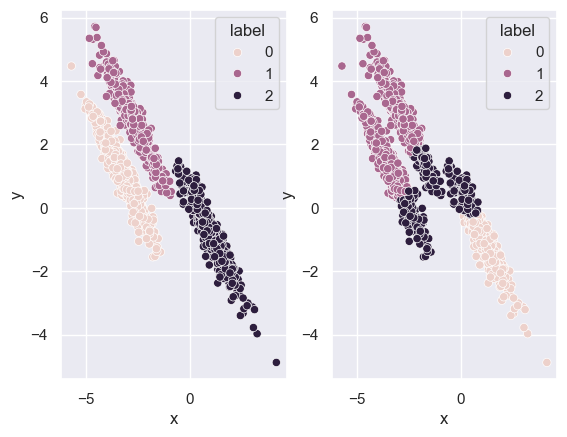

In [102]:
labels = AgglomerativeClustering(n_clusters=3,linkage="complete").fit(X_aniso).labels_
df_aniso_pred = pd.DataFrame({'x':X_aniso[:,0], 'y':X_aniso[:,1], 'label': labels})
fig, axs = plt.subplots(ncols=2)
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_aniso, ax=axs[0])
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_aniso_pred, ax=axs[1])

## DENSIDAD: DBScan

In [103]:
from sklearn.cluster import DBSCAN

### Conjuntos de datos para los que muestra un BUEN funcionamiento

### Conjuntos de datos para los que muestra un MAL funcionamiento

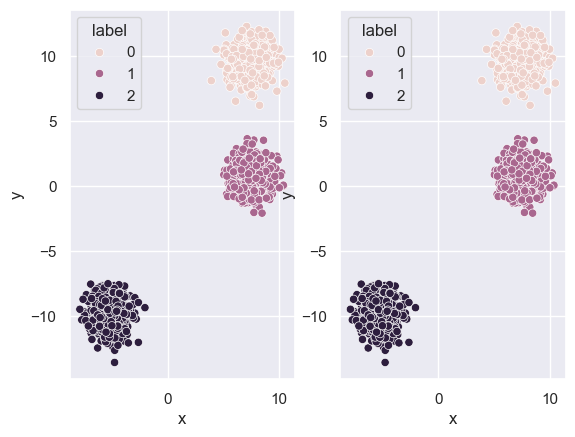

In [104]:
labels = DBSCAN(eps=1.5).fit(blobs[0]).labels_
df_blobs_pred = pd.DataFrame({'x':blobs[0][:,0], 'y':blobs[0][:,1], 'label': labels})
fig, axs = plt.subplots(ncols=2)
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_blobs, ax=axs[0])
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_blobs_pred, ax=axs[1])

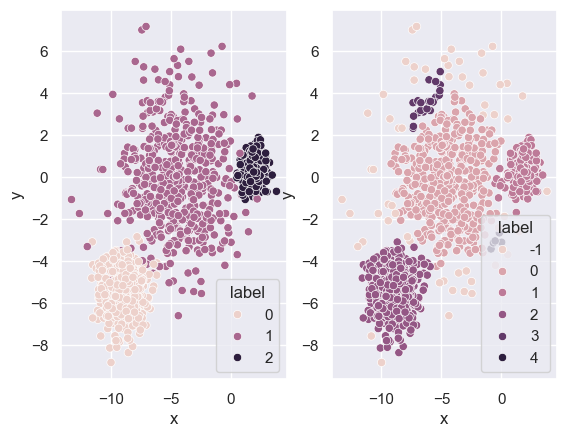

In [105]:
labels = DBSCAN(eps= 0.65).fit(varied[0]).labels_
df_varied_pred = pd.DataFrame({'x':varied[0][:,0], 'y':varied[0][:,1], 'label': labels})
fig, axs = plt.subplots(ncols=2)
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_varied, ax=axs[0])
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_varied_pred, ax=axs[1])

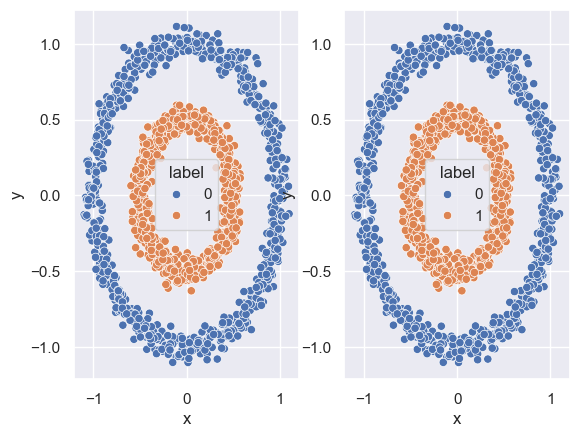

In [106]:
labels = DBSCAN(eps=0.2).fit(noisy_circles[0]).labels_
df_noisy_circles_pred = pd.DataFrame({'x':noisy_circles[0][:,0], 'y':noisy_circles[0][:,1], 'label': labels})
fig, axs = plt.subplots(ncols=2)
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_noisy_circles, ax=axs[0])
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_noisy_circles_pred, ax=axs[1])

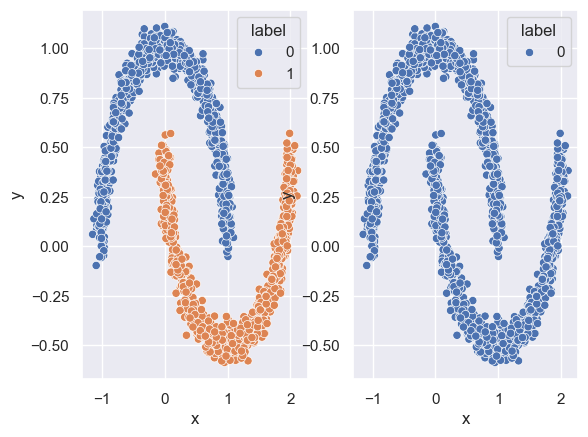

In [107]:
labels = DBSCAN(eps=0.3).fit(noisy_moons[0]).labels_
df_noisy_moons_pred = pd.DataFrame({'x':noisy_moons[0][:,0], 'y':noisy_moons[0][:,1], 'label': labels})
fig, axs = plt.subplots(ncols=2)
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_noisy_moons, ax=axs[0])
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_noisy_moons_pred, ax=axs[1])

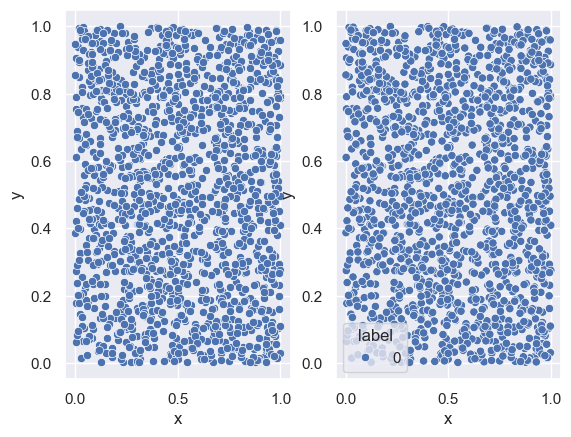

In [108]:
labels = DBSCAN(eps=0.5).fit(no_structure[0]).labels_
df_no_structure_pred = pd.DataFrame({'x':no_structure[0][:,0], 'y':no_structure[0][:,1], 'label': labels})
fig, axs = plt.subplots(ncols=2)
ax = sns.scatterplot(x='x', y='y', data=df_no_structure, ax=axs[0])
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_no_structure_pred, ax=axs[1])

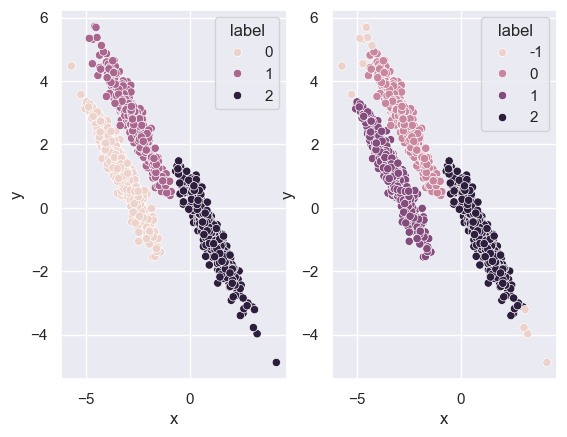

In [109]:
# Es complicado definir eps
labels = DBSCAN(eps=0.35).fit(X_aniso).labels_
df_aniso_pred = pd.DataFrame({'x':X_aniso[:,0], 'y':X_aniso[:,1], 'label': labels})
fig, axs = plt.subplots(ncols=2)
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_aniso, ax=axs[0])
ax = sns.scatterplot(x='x', y='y', hue='label', data=df_aniso_pred, ax=axs[1])

## Número óptimo de particiones

### Método Elbow

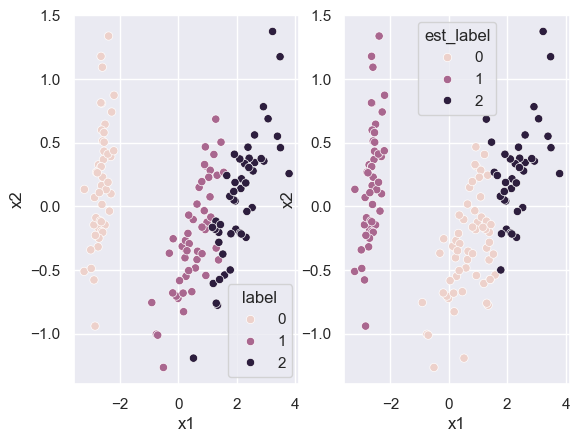

In [110]:
from sklearn.decomposition import PCA
X, y = datasets.load_iris(return_X_y=True)

#Apliquemos PCA con dos componentes principales
X_pca = PCA(n_components=2).fit_transform(X)


kmeans = KMeans(n_clusters=3).fit(X_pca)
km_df = pd.DataFrame(X_pca, columns=['x1', 'x2'])
km_df['label']=y
km_df['est_label']=kmeans.labels_

fig, axs = plt.subplots(ncols=2)
ax = sns.scatterplot(x='x1', y='x2', hue='label', data=km_df, ax=axs[0])
ax = sns.scatterplot(x='x1', y='x2', hue='est_label', data=km_df, ax=axs[1])

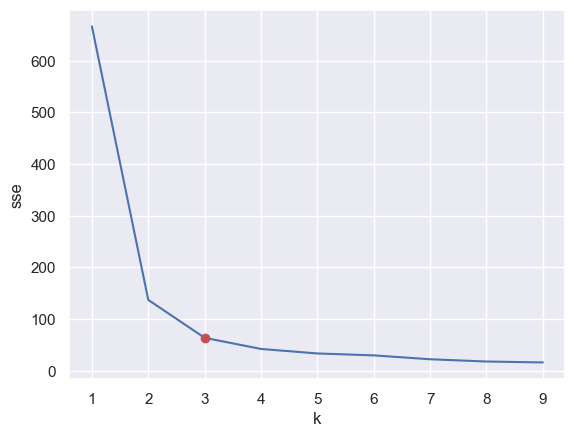

In [111]:
sse = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k).fit(X_pca)
    sse.append((k, kmeans.inertia_))
               
df = pd.DataFrame(sse, columns=['k', 'sse'])
ax = sns.lineplot(x='k', y='sse', data=df)
ax = ax.plot(sse[2][0],sse[2][1],'ro')

### Método Silhouette

In [112]:
from sklearn.metrics import silhouette_score

for n_cluster in range(2, 11):
    kmeans = KMeans(n_clusters= n_cluster).fit(X)
    sil_coeff = silhouette_score(X,kmeans.labels_,metric="euclidean")
    print("For n_clusters={}, The Silhouette Coefficient is {}".format(n_cluster, sil_coeff))

For n_clusters=2, The Silhouette Coefficient is 0.6810461692117462
For n_clusters=3, The Silhouette Coefficient is 0.551191604619592
For n_clusters=4, The Silhouette Coefficient is 0.49535632852884987
For n_clusters=5, The Silhouette Coefficient is 0.4279149330800647
For n_clusters=6, The Silhouette Coefficient is 0.3557536089245232
For n_clusters=7, The Silhouette Coefficient is 0.3519706106126843
For n_clusters=8, The Silhouette Coefficient is 0.3216815040642888
For n_clusters=9, The Silhouette Coefficient is 0.28860828488158197
For n_clusters=10, The Silhouette Coefficient is 0.41187809329280517


### Calinski Harabaz

In [115]:
from sklearn.metrics import calinski_harabasz_score

for n_cluster in range(2, 11):
    kmeans = KMeans(n_clusters=n_cluster).fit(X)
    cal_score = calinski_harabasz_score(X,kmeans.labels_)
    print("For n_clusters={}, The Calinski Harabaz Score is {}".format(n_cluster,cal_score))

For n_clusters=2, The Calinski Harabaz Score is 513.9245459802768
For n_clusters=3, The Calinski Harabaz Score is 270.8094692325412
For n_clusters=4, The Calinski Harabaz Score is 530.4871420421675
For n_clusters=5, The Calinski Harabaz Score is 495.24341371472747
For n_clusters=6, The Calinski Harabaz Score is 433.78270253075715
For n_clusters=7, The Calinski Harabaz Score is 414.7543840670088
For n_clusters=8, The Calinski Harabaz Score is 388.1201953176885
For n_clusters=9, The Calinski Harabaz Score is 367.0576744347872
For n_clusters=10, The Calinski Harabaz Score is 374.85352371278185


## Dendograma
Fuente: https://github.com/scikit-learn/scikit-learn/blob/70cf4a676caa2d2dad2e3f6e4478d64bcb0506f7/examples/cluster/plot_hierarchical_clustering_dendrogram.py

In [117]:
from scipy.cluster.hierarchy import dendrogram

def plot_dendrogram(model, **kwargs):

    # Children of hierarchical clustering
    children = model.children_

    # Distances between each pair of children
    # Since we don't have this information, we can use a uniform one for plotting
    distance = np.arange(children.shape[0])

    # The number of observations contained in each cluster level
    no_of_observations = np.arange(2, children.shape[0]+2)

    # Create linkage matrix and then plot the dendrogram
    linkage_matrix = np.column_stack([children, distance, no_of_observations]).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

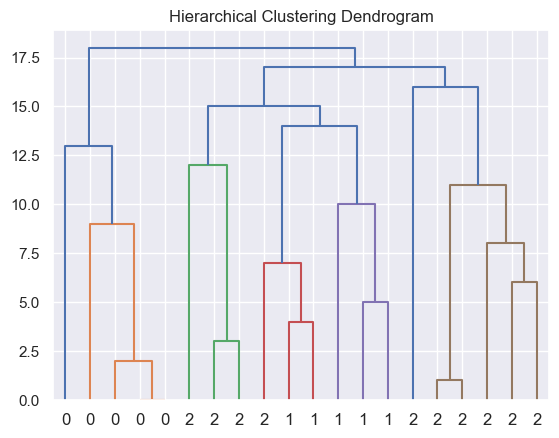

In [118]:
X, y = datasets.load_iris(return_X_y=True)
index = np.random.randint(0, 150, 20)
X_batch = X[index]
hier_model = AgglomerativeClustering(n_clusters=3).fit(X_batch)

plt.title('Hierarchical Clustering Dendrogram')
plot_dendrogram(hier_model, labels=y[index])
plt.show()

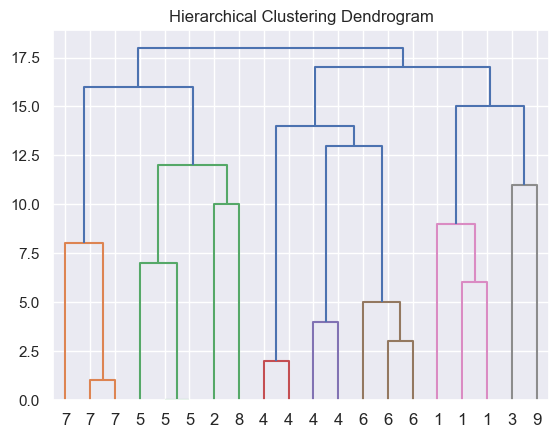

In [120]:
X, y = datasets.load_digits(return_X_y=True)
index = np.random.randint(0, 150, 20)
X_batch = X[index]
hier_model = AgglomerativeClustering(n_clusters=10).fit(X_batch)

plt.title('Hierarchical Clustering Dendrogram')
plot_dendrogram(hier_model, labels=y[index])
plt.show()